# **MACROCASO 02 - LIMPIEZA Y ANÁLISIS**


In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
import unicodedata
import nltk
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
import community
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
import community
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
import nltk
nltk.download('punkt_tab')
import spacy
from tqdm import tqdm
import matplotlib.pyplot as plt
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import unicodedata
nlp = spacy.load("es_core_news_sm")
from unidecode import unidecode


In [6]:
carpeta ="C:/Users/yulis/OneDrive/Desktop/Casos_JEP/caso_02"

textos_raul = []
textos_navarro = []
textos_otros = []

for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()

        # normalizar: minúsculas, quitar tildes y signos
        archivo_norm = unidecode(archivo.lower())
        archivo_norm = archivo_norm.replace(',', '').replace('-', ' ').replace('_', ' ')

        if 'raul delgado' in archivo_norm:
            textos_raul.append((archivo, contenido))
        elif 'navarro wolff' in archivo_norm:
            textos_navarro.append((archivo, contenido))
        else:
            textos_otros.append((archivo, contenido))

texto_raul = ' '.join([contenido for _, contenido in textos_raul])
texto_navarro = ' '.join([contenido for _, contenido in textos_navarro])

print(f"Archivos de Raúl Delgado: {len(textos_raul)}")
print(f"Archivos de Navarro Wolff: {len(textos_navarro)}")
print(f"Otros archivos: {len(textos_otros)}")

Archivos de Raúl Delgado: 1
Archivos de Navarro Wolff: 1
Otros archivos: 0


In [74]:
#FUNCIONES DE LIMPIEZA DE TEXTO
from nltk.tokenize import word_tokenize

def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    # Tokenizar el texto
    tokens = word_tokenize(texto)

    # Quitar stopwords
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}  # palabras que no queremos eliminar como UP(unión patriótica) y fe
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado

In [73]:
# Cargar el diccionario de lematizaciones:
lematizaciones = {}
with open('C:/Users/yulis/OneDrive/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

def aplicar_lematizacion(texto, lematizaciones):
    palabras = texto.split()
    palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
    return ' '.join(palabras_lematizadas)
textos = {
    'Raúl Delgado': texto_raul,
    'A. Navarro Wolff': texto_navarro
}

textos_lematizados = {}
for nombre, texto in textos.items():
    textos_lematizados[nombre] = aplicar_lematizacion(texto, lematizaciones)

texto_raul_lem = textos_lematizados['Raúl Delgado']
texto_navarro_lem = textos_lematizados['A. Navarro Wolff']

#Eliminar palabras cortas:
texto_raul_final = eliminar_palabras_cortas(texto_raul_lem)
texto_navarro_final = eliminar_palabras_cortas(texto_navarro_lem)

textos = {
    'Raúl Delgado': texto_raul_final,
    'A. Navarro Wolff': texto_navarro_final
}
tokens_dict = {}
for nombre, texto in textos.items():
    tokens = nltk.word_tokenize(texto, language="spanish")
    tokens_dict[nombre] = tokens

# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# palabras que NO deben lematizarse

excepciones = {"voluntaria", "soldado"}
nlp = spacy.load("es_core_news_md", disable=["parser","ner"])

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser","ner"])
        for tok_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if tok_original.lower() in excepciones:
                lemas.append(tok_original.lower())
            else:
                lemas.append(token_spacy.lemma_)
    return lemas
for nombre, tokens in tokens_dict.items():
    print(f"\n Procesando texto: {nombre} ({len(tokens)} tokens)")
    lemas = lematizar_en_bloques(tokens, bloque_size=10000)
    nombre_archivo = f"solo_lemas_{nombre}.txt"

    with open(nombre_archivo, "w", encoding="utf-8") as f:
        for lema in lemas:
            f.write(lema + "\n")



 Procesando texto: Raúl Delgado (12080 tokens)


100%|██████████| 2/2 [00:05<00:00,  2.60s/it]



 Procesando texto: A. Navarro Wolff (11614 tokens)


100%|██████████| 2/2 [00:04<00:00,  2.15s/it]


In [71]:
#──────── reconstruir textos ───────────────────────────────
textos_lemas = {}

for nombre in ["Raúl Delgado", "A. Navarro Wolff"]:
    with open(f"solo_lemas_{nombre}.txt", "r", encoding="utf-8") as f:
        lemas = [line.strip() for line in f if line.strip()]
    texto_lemas = " ".join(lemas)
    textos_lemas[nombre] = texto_lemas


#───── Aplicar la lematización personalizada ───────────────────────────────
lematizaciones2 = {}
with open('C:/Users/yulis/OneDrive/Desktop/Casos_JEP/salida_02.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

textos_finales_dicc = {}

for nombre, texto in textos_lemas.items():
    palabras = texto.split()

    texto_lemas_dicc = []
    for palabra in palabras:
        if palabra in lematizaciones2:
            if lematizaciones2[palabra] != "NA":
                texto_lemas_dicc.append(lematizaciones2[palabra])
            # si es "NA", no se agrega nada (se elimina)
        else:
            texto_lemas_dicc.append(palabra)
    texto_final = " ".join(texto_lemas_dicc)
    textos_finales_dicc[nombre] = texto_final


# **GENERAR SKIPGRAMAS**

In [ ]:
def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# ── Cargar stopwords  ───────────────────────────────
stop_words = set(stopwords.words('spanish'))

archivo_stopwords = 'C:/Users/yulis/OneDrive/Desktop/Casos_JEP/stop_words_espanol.txt'
with open(archivo_stopwords, 'r', encoding='utf-8') as f:
    for linea in f:
        word = linea.strip()
        stop_words.add(word)
        for palabra in linea.split():
            stop_words.add(eliminar_acentos(palabra.lower()))

# ----------------------- Cargar palabras no válidas -----------------------------
ruta_palabras = "C:/Users/yulis/OneDrive/Desktop/Casos_JEP/palabras_no_validas.txt"
with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

# ------------------------ Cargar lematizaciones ---------------------------------
ruta_lemas = "C:/Users/yulis/OneDrive/Desktop/Casos_JEP/lemas_lemas.txt"
lemas_set = set()
lematizaciones_final = {}
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for linea in f:
        if ":" in linea:
            palabra, lema = linea.strip().split(":", 1)
            lemas_set.add(palabra.strip())
            lematizaciones_final[normalizar(palabra.strip())] = normalizar(lema.strip())

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

# ------------------------- Limpiar texto -----------------------------------------
textos_finales_limpios = {}
for nombre, texto_final in textos_finales_dicc.items():
    print(f"\nLimpiando texto: {nombre}")
    textos_finales_limpios[nombre] = limpiar_texto(texto_final)
    print(f"Texto '{nombre}' limpiado.")

# -------------------------- Lematizar ---------------------------------------------
textos_lema_dicc = {}
for nombre, texto_final_limpio in textos_finales_limpios.items():
    print(f"\nLematizando texto: {nombre}")
    palabras = texto_final_limpio.split()
    palabras_lematizadas = [lematizaciones_final.get(palabra, palabra) for palabra in palabras]
    textos_lema_dicc[nombre] = " ".join(palabras_lematizadas)

# ------------------- Filtrar palabras no válidas ----------------------------------
textos_filtrados = {}
for nombre, texto_lema in textos_lema_dicc.items():
    palabras = texto_lema.split()
    textos_filtrados[nombre] = " ".join([p for p in palabras if p not in filtradas])

# ---------------- Generar skipgramas y remover stopwords ----------------------------
textos_skipgramas = {}
for nombre, texto_filtrado in textos_lema_dicc.items():
    print(f"\nProcesando texto: {nombre}")
    texto_sin_stopwords = quitar_stopwords(texto_filtrado)
    tokens = word_tokenize(texto_sin_stopwords)
    frec = Counter(tokens)
    tokens_filtrados = [t for t in tokens if frec[t] > 1]
    texto_dep = " ".join(tokens_filtrados)
    skipgramas = generar_skipgramas(texto_dep, 2, 2)
    textos_skipgramas[nombre] = {
        "texto_sin_stopwords": texto_dep,
        "skipgramas": skipgramas
    }


Limpiando texto: Raúl Delgado
Texto 'Raúl Delgado' limpiado.

Limpiando texto: A. Navarro Wolff
Texto 'A. Navarro Wolff' limpiado.

Lematizando texto: Raúl Delgado

Lematizando texto: A. Navarro Wolff

Procesando texto: Raúl Delgado

Procesando texto: A. Navarro Wolff


In [55]:
##eliminar bucles en skipgramas
textos_skipgramas_filtrados = {}

for nombre, datos in textos_skipgramas.items():
    skipgramas = datos["skipgramas"]

    # Eliminar bucles (a, a)
    skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
    conteo = Counter(skipgramas_sin_bucles)
    # Conservar solo los skipgramas con frecuencia > 1
    skipgramas_filtrados = [b for b, f in conteo.items() if f > 1]

    # Guardar en diccionario
    textos_skipgramas_filtrados[nombre] = {
        "texto_sin_stopwords": datos["texto_sin_stopwords"],
        "skipgramas_filtrados": skipgramas_filtrados,
        "frecuencias": conteo}

#calcular frecuencias
tablas_frecuencias = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    conteo = datos["frecuencias"]
    conteo_str = {' '.join(k): v for k, v in conteo.items() if v > 1}
    df_top = pd.DataFrame(Counter(conteo_str).most_common(10), columns=["Skipgrama", "Frecuencia"])
    tablas_frecuencias[nombre] = df_top

    print(f"\nTop 10 skipgramas en '{nombre}':")
    display(df_top)


Top 10 skipgramas en 'Raúl Delgado':


,Skipgrama,Frecuencia
0,gobierno nacional,35
1,aspersion glifosato,19
2,cultivo ilicito,17
3,fuerza publico,16
4,municipio tumaco,15
5,pueblo indigena,15
6,departamento narino,14
7,expresion glifosato,14
8,comunidad indigena,14
9,tumaco ricaurte,12



Top 10 skipgramas en 'A. Navarro Wolff':


,Skipgrama,Frecuencia
0,gobierno nacional,39
1,cultivo ilicito,29
2,sustituir voluntaria,20
3,aspersion glifosato,18
4,erradicacion cultivo,15
5,judicial victima,13
6,erradicacion ilicito,13
7,secretario gobierno,13
8,leiva rosario,13
9,departamento narino,12


# **ANÁLISIS DESCRIPTIVO**

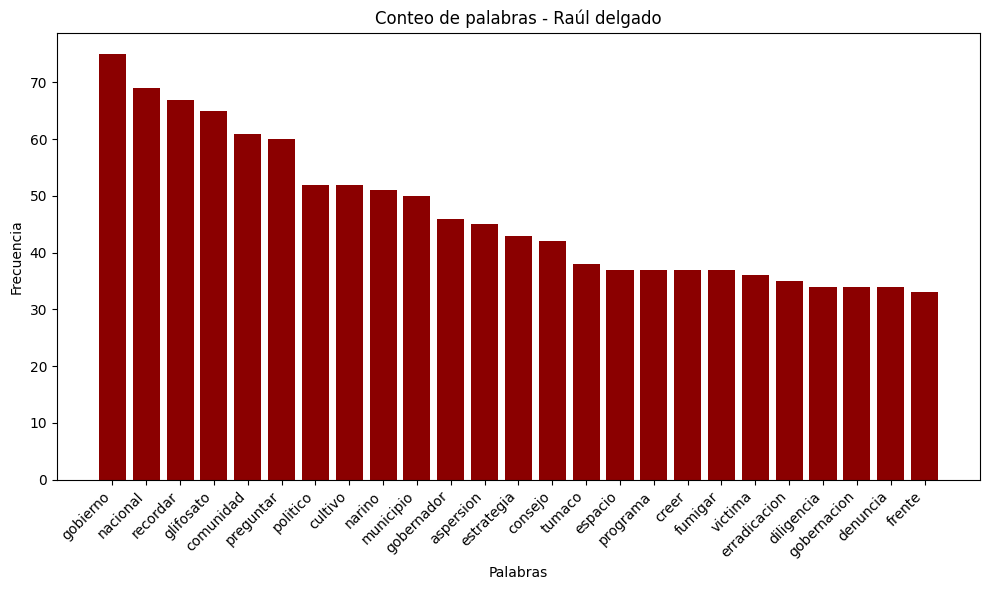

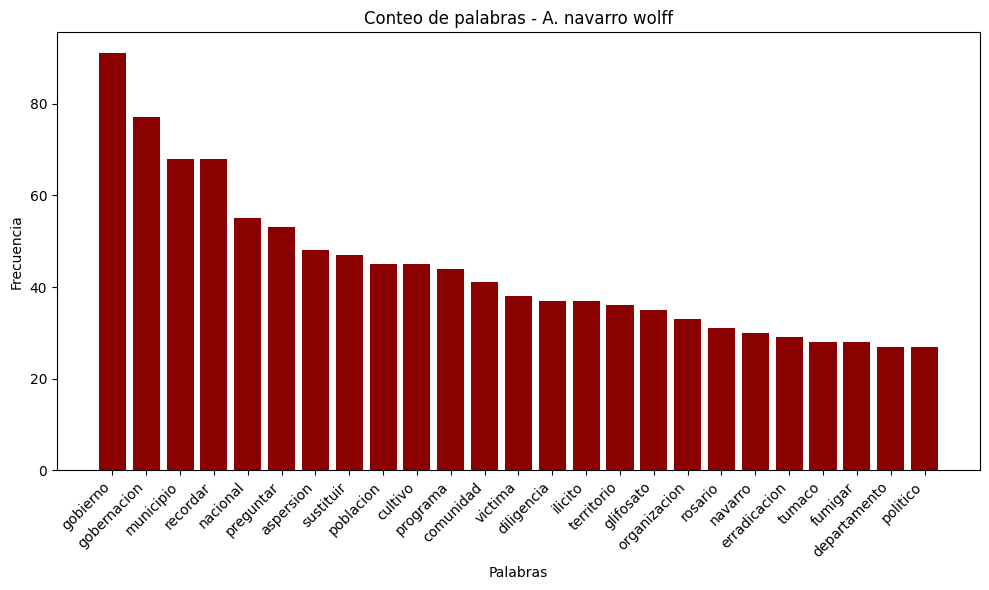

In [56]:
##Distribución de frecuencias
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()

    if len(tokens) == 0:
        print(f"El grupo '{nombre}' no tiene palabras para analizar.")
        continue
    # Calcular frecuencias
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(25)
    palabras, frecuencias = zip(*palabras_repetidas)

    # Graficar por subanáliss:
    plt.figure(figsize=(10, 6))
    plt.bar(palabras, frecuencias, color="darkred")
    plt.xlabel('Palabras')
    plt.ylabel('Frecuencia')
    plt.title(f"Conteo de palabras - {nombre.capitalize()}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [57]:
##Frecuencia de palabras por subanálisis:
tablas_frecuencias = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = texto.split()

    # Calcular frecuencias
    frecuencia_palabras = FreqDist(tokens)
    palabras_repetidas = frecuencia_palabras.most_common(15)

    tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
    tablas_frecuencias[nombre] = tabla_frecuencias

    print(f"\n Frecuencias para: {nombre}")
    print(tabla_frecuencias)

tabla_final = pd.concat(tablas_frecuencias, names=['Grupo']).reset_index(level=0)
tabla_final.reset_index(drop=True, inplace=True)


 Frecuencias para: Raúl Delgado
       Palabra  Frecuencia
0     gobierno          75
1     nacional          69
2     recordar          67
3    glifosato          65
4    comunidad          61
5    preguntar          60
6     politico          52
7      cultivo          52
8       narino          51
9    municipio          50
10  gobernador          46
11   aspersion          45
12  estrategia          43
13     consejo          42
14      tumaco          38

 Frecuencias para: A. Navarro Wolff
        Palabra  Frecuencia
0      gobierno          91
1   gobernacion          77
2     municipio          68
3      recordar          68
4      nacional          55
5     preguntar          53
6     aspersion          48
7     sustituir          47
8     poblacion          45
9       cultivo          45
10     programa          44
11    comunidad          41
12      victima          38
13   diligencia          37
14      ilicito          37


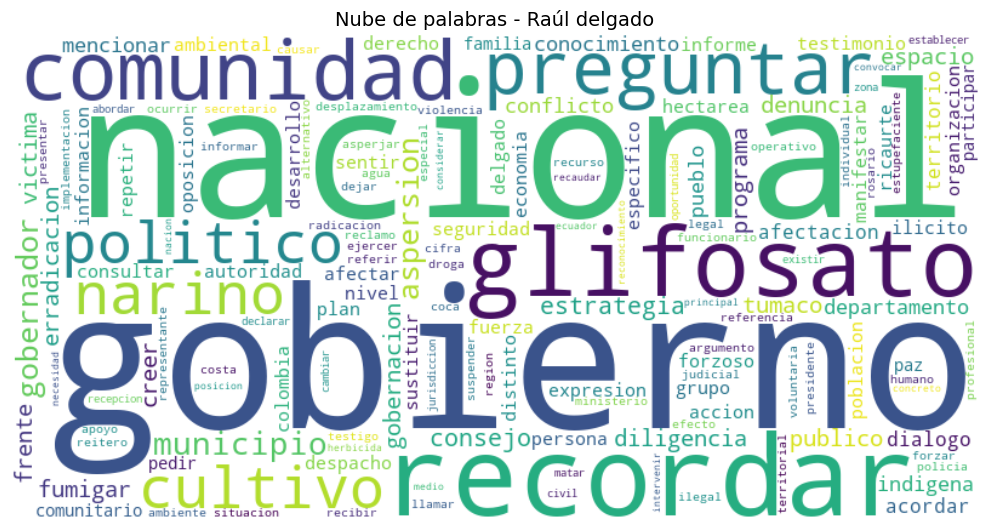

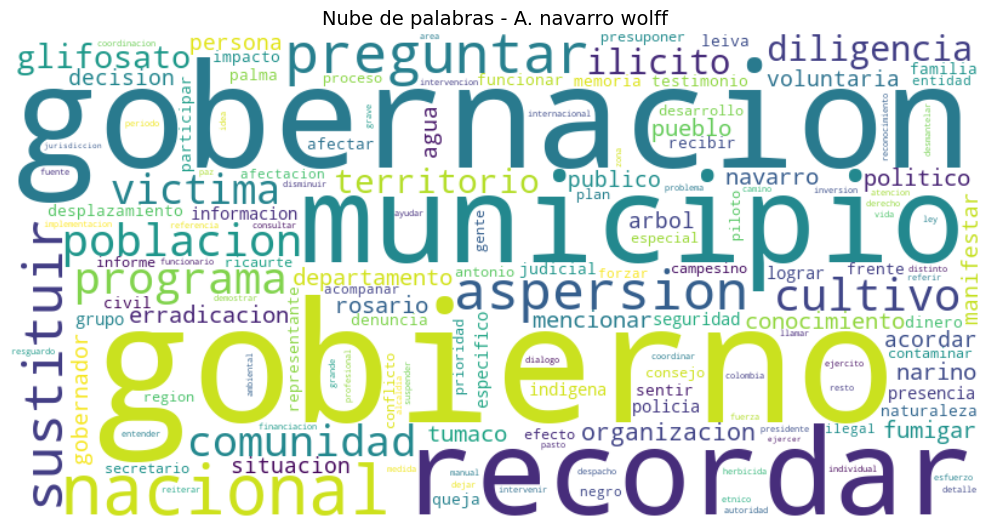

In [58]:
#  Crear nube de palabras para cada grupo de análisis

for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    tokens = texto.split()
    if len(tokens) == 0:
        print(f" El grupo '{nombre}' no tiene palabras para analizar.")
        continue
    frecuencia_palabras = FreqDist(tokens)

    # Crear la nube de palabras
    nube =  WordCloud(width=800, height=400,
        background_color='white',
        max_words=150
    ).generate_from_frequencies(frecuencia_palabras)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nube de palabras - {nombre.capitalize()}", fontsize=14)
    plt.tight_layout()
    plt.show()


# **ANÁLISIS DE SENTIMIENTO**

In [67]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/yulis/OneDrive/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

lexico['Palabra'] = (
    lexico['Palabra'].astype(str).str.lower().str.strip().apply(unidecode).str.replace(r'[^a-zñáéíóúü\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True))

columnas_emociones = [
    'Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')


resultados = []
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]

    # Normalizar
    tokens = [ re.sub(r'\s+', ' ',re.sub(r'[^a-zñáéíóúü\s]', '',
                      unidecode(t.lower().strip())))
        for t in word_tokenize(texto)]

    conteo = Counter({emo: 0 for emo in columnas_emociones})

    for token in tokens:
        if token in emociones:
            for emo, valor in emociones[token].items():
                conteo[emo] += valor

    conteo['Texto'] = nombre
    resultados.append(conteo)

df_emociones = pd.DataFrame(resultados)
df_emociones = df_emociones[['Texto'] + columnas_emociones]

# Traducir nombres de columnas
df_emociones = df_emociones.rename(columns={'Positive': 'Positivo','Negative': 'Negativo','Anger': 'Ira',
    'Anticipation': 'Anticipación','Disgust': 'Disgusto','Fear': 'Miedo','Joy': 'Alegría','Sadness': 'Tristeza',
    'Surprise': 'Sorpresa', 'Trust': 'Confianza'})
print(df_emociones.head())


              Texto  Positivo  Negativo  Ira  Anticipación  Disgusto  Miedo  \
0      Raúl Delgado       961       507  312           262       161    401   
1  A. Navarro Wolff       839       507  277           231       212    373   

   Alegría  Tristeza  Sorpresa  Confianza  
0      121       189        97        630  
1      161       184       122        489  


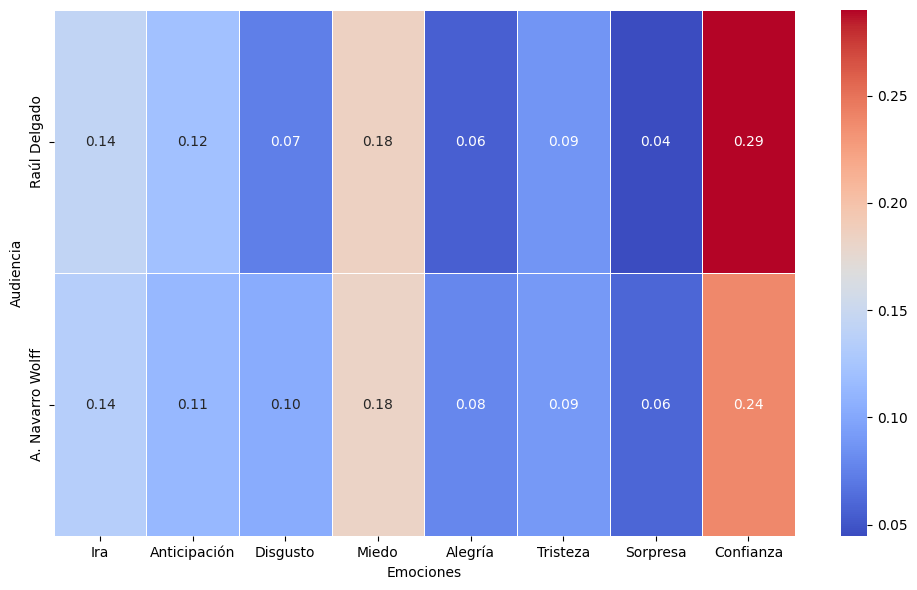

In [60]:
#Mapa de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Audiencia')
plt.tight_layout()
plt.show()


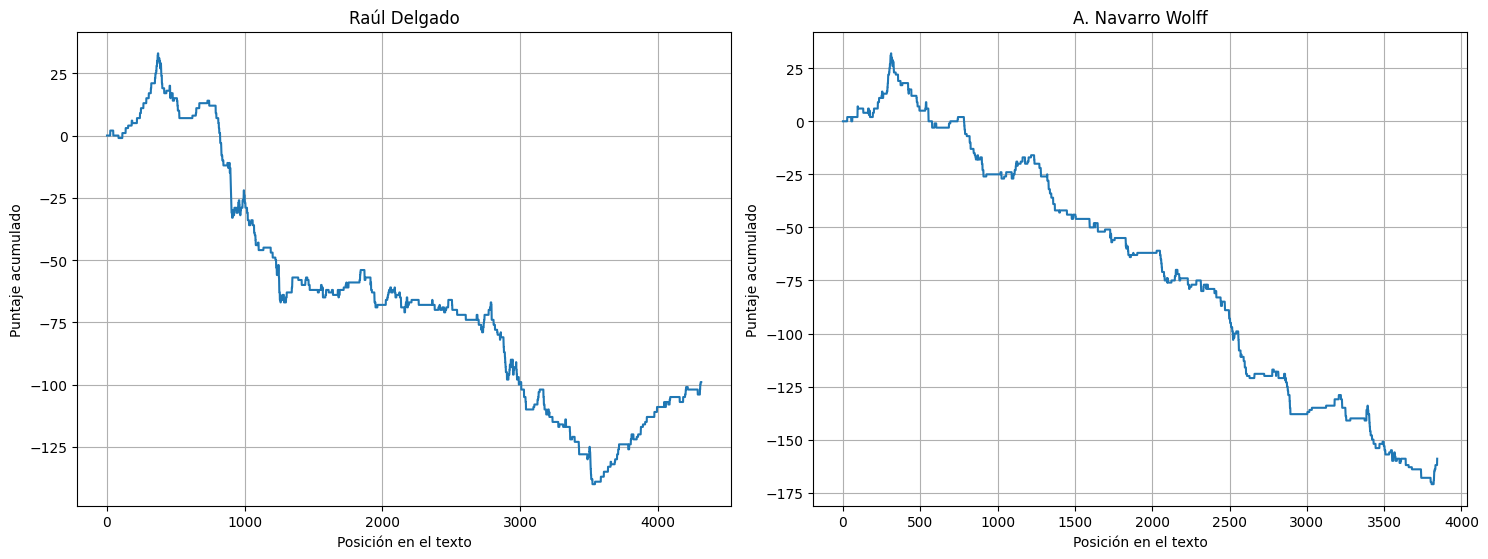

In [61]:
##Grafico de sentimiento acumulado mediante diccionario AFINN
afinn = pd.read_csv("C:/Users/yulis/OneDrive/Desktop/Casos_JEP/material_adicional/lexico_afinn.csv")
afinn['palabra'] = afinn['palabra'].str.lower().str.strip()
afinn_dict = dict(zip(afinn['palabra'], afinn['puntuacion']))

tendencias_afinn = {}
for nombre, datos in textos_skipgramas_filtrados.items():
    texto = datos["texto_sin_stopwords"]
    tokens = [
        unidecode(t.lower().strip())
        for t in word_tokenize(texto)]
    puntajes = [
        afinn_dict.get(token, 0)
        for token in tokens]

    df = pd.DataFrame({"palabra": tokens, "puntaje": puntajes})
    df["sentimiento_acumulado"] = df["puntaje"].cumsum()
    tendencias_afinn[nombre] = df

#grafico:
n = len(tendencias_afinn)
ncols = 2
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 6* nrows))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, tendencias_afinn.items()):
    ax.plot(df.index, df["sentimiento_acumulado"])
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Posición en el texto")
    ax.set_ylabel("Puntaje acumulado")
    ax.grid(True)

for i in range(len(tendencias_afinn), len(axes)):
    axes[i].axis("off")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()





# **RED BASICA**

In [66]:
# ── Función auxiliar (fuera del bucle) ───────────────────────────────
def get_gigante(G):
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()

# ── Cálculo de métricas ───────────────────────────────────────────────
redes_metrics = {}
centralidades_por_red = {}
top10_grado_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = get_gigante(G)

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    # Métricas básicas
    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())

    # Top 10 por grado
    top10_grado = (
        pd.DataFrame(grados.items(), columns=["nodo", "grado"])
        .sort_values("grado", ascending=False)
        .head(10)
        .assign(porcentaje_grado=lambda x: x["grado"] / (2 * num_aristas))
    )
    top10_grado_por_red[nombre] = top10_grado

    # Centralidades
    nodos = list(G_gigante.nodes())
    betweenness = nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42)
    closeness = nx.closeness_centrality(G_gigante)
    eigenvector = nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6)

    df_centralidad = pd.DataFrame({
        "nodo": nodos,
        "grado": [grados[n] for n in nodos],
        "betweenness": [betweenness[n] for n in nodos],
        "closeness": [closeness[n] for n in nodos],
        "eigenvector": [eigenvector[n] for n in nodos]
    })
    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "num_aristas": num_aristas,
        "densidad": nx.density(G_gigante),
        "grado_promedio": sum(grados.values()) / num_nodos,
        "transitividad_global": nx.transitivity(G_gigante),
        "assortatividad_grado": nx.degree_assortativity_coefficient(G_gigante),
        "diametro": nx.diameter(G_gigante),
        "longitud_media_camino": nx.average_shortest_path_length(G_gigante),
        "betweenness_media": df_centralidad["betweenness"].mean(),
        "betweenness_max": df_centralidad["betweenness"].max(),
        "closeness_media": df_centralidad["closeness"].mean(),
        "eigenvector_media": df_centralidad["eigenvector"].mean(),
        "grado_max": top10_grado["grado"].max(),
        "grado_medio_top10": top10_grado["grado"].mean(),
        "concentracion_top10": top10_grado["grado"].sum() / (2 * num_aristas),
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print("\nMétricas")
print(df_metrics)

Grafo 'Raúl Delgado': 453 nodos, 1626 aristas (componente gigante).
Grafo 'A. Navarro Wolff': 435 nodos, 1366 aristas (componente gigante).

Métricas
                  num_nodos  num_aristas  densidad  grado_promedio  \
Raúl Delgado            453         1626  0.015882        7.178808   
A. Navarro Wolff        435         1366  0.014471        6.280460   

                  transitividad_global  assortatividad_grado  diametro  \
Raúl Delgado                  0.192551             -0.053132         7   
A. Navarro Wolff              0.176752             -0.090429         7   

                  longitud_media_camino  betweenness_media  betweenness_max  \
Raúl Delgado                   3.216033           0.004914         0.101728   
A. Navarro Wolff               3.320949           0.005360         0.149294   

                  closeness_media  eigenvector_media  grado_max  \
Raúl Delgado             0.318428           0.025374         74   
A. Navarro Wolff         0.308689           

In [63]:
top10_grado_por_red

{'Raúl Delgado':           nodo  grado  porcentaje_grado
 93    gobierno     74          0.022755
 169   recordar     69          0.021218
 130  glifosato     67          0.020603
 70    nacional     63          0.019373
 148  comunidad     59          0.018143
 162  preguntar     55          0.016913
 137    cultivo     51          0.015683
 126   politico     48          0.014760
 46   municipio     46          0.014145
 47      narino     45          0.013838,
 'A. Navarro Wolff':             nodo  grado  porcentaje_grado
 72      gobierno     80          0.029283
 169  gobernacion     77          0.028184
 149     recordar     69          0.025256
 112    municipio     54          0.019766
 156    preguntar     45          0.016471
 95     comunidad     44          0.016105
 84     poblacion     44          0.016105
 78    territorio     42          0.015373
 73      nacional     42          0.015373
 123    aspersion     40          0.014641}

In [ ]:
def max_info(df, col):
    idx = df[col].idxmax()
    return df.loc[idx, col], df.loc[idx, "nodo"]

# ── Cálculo de centralidad ────────────────────────────────────────────
redes_metrics = {}
centralidades_por_red = {}

for nombre, datos in textos_skipgramas_filtrados.items():
    skipgramas = datos["skipgramas_filtrados"]

    G = nx.Graph()
    G.add_edges_from(skipgramas)

    if G.number_of_nodes() == 0:
        print(f"Grafo '{nombre}' vacío.")
        continue

    G_gigante = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    if G_gigante.number_of_nodes() < 2:
        print(f"Grafo '{nombre}' con componente gigante muy pequeña.")
        continue

    num_nodos = G_gigante.number_of_nodes()
    num_aristas = G_gigante.number_of_edges()
    grados = dict(G_gigante.degree())
    grado_promedio = sum(grados.values()) / num_nodos

    df_centralidad = pd.DataFrame({
        "nodo": list(G_gigante.nodes()),
        "grado": [grados[n] for n in G_gigante.nodes()],
        "betweenness": list(nx.betweenness_centrality(G_gigante, k=min(500, num_nodos), normalized=True, seed=42).values()),
        "closeness": list(nx.closeness_centrality(G_gigante).values()),
        "eigenvector": list(nx.eigenvector_centrality(G_gigante, max_iter=1000, tol=1e-6).values())
    })

    centralidades_por_red[nombre] = df_centralidad

    redes_metrics[nombre] = {
        "num_nodos": num_nodos,
        "grado_promedio": grado_promedio,
        "grado_max": max_info(df_centralidad, "grado")[0],
        "nodo_grado_max": max_info(df_centralidad, "grado")[1],
        "betweenness_max": max_info(df_centralidad, "betweenness")[0],
        "nodo_betweenness_max": max_info(df_centralidad, "betweenness")[1],
        "closeness_max": max_info(df_centralidad, "closeness")[0],
        "nodo_closeness_max": max_info(df_centralidad, "closeness")[1],
        "eigenvector_max": max_info(df_centralidad, "eigenvector")[0],
        "nodo_eigenvector_max": max_info(df_centralidad, "eigenvector")[1],
    }

    print(f"Grafo '{nombre}': {num_nodos} nodos, {num_aristas} aristas (componente gigante).")

df_metrics = pd.DataFrame.from_dict(redes_metrics, orient="index")
print(df_metrics)

Grafo 'Raúl Delgado': 453 nodos, 1626 aristas (componente gigante).
Grafo 'A. Navarro Wolff': 435 nodos, 1366 aristas (componente gigante).
                  num_nodos  grado_promedio  grado_max nodo_grado_max  \
Raúl Delgado            453        7.178808         74       gobierno   
A. Navarro Wolff        435        6.280460         80       gobierno   

                  betweenness_max nodo_betweenness_max  closeness_max  \
Raúl Delgado             0.101728            preguntar       0.485499   
A. Navarro Wolff         0.149294             gobierno       0.462194   

                 nodo_closeness_max  eigenvector_max nodo_eigenvector_max  
Raúl Delgado               recordar         0.249862             recordar  
A. Navarro Wolff           recordar         0.283620          gobernacion  
